# LangGraph QuickStart

LangGraph는 상태 기반 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

## 구현 기능

- 상태 관리 기반 챗봇
- 외부 도구 연동 (Tavily Search)
- 메모리 및 체크포인트
- Human-in-the-Loop
- 상태 커스터마이징

## 환경 설정

LangGraph를 사용하기 위해 필요한 환경 변수와 로깅을 설정합니다. `.env` 파일에 API 키를 저장하고, LangSmith를 통해 실행 과정을 추적할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


---

## 기본 챗봇 구축

메시지 기반 챗봇을 StateGraph로 구성합니다. StateGraph는 LangGraph의 핵심 구성 요소로, 노드와 엣지를 연결하여 상태 기반 워크플로우를 정의합니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

### 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| StateGraph | 전체 워크플로우 흐름을 정의하는 그래프 |
| State | 그래프 실행 중 데이터를 저장하는 상태 객체 |
| Node | 실제 작업을 수행하는 함수 (예: LLM 호출) |
| Edge | 노드 간 실행 경로를 연결 |
| Compile/Invoke | 그래프를 실행 가능한 형태로 변환 및 호출 |

아래 코드는 State 타입을 정의하고 StateGraph 인스턴스를 생성합니다.

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의: 챗봇의 상태를 나타내는 타입
class State(TypedDict):
    """챗봇의 상태를 정의하는 타입

    messages: 대화 메시지 리스트
    - add_messages 함수를 통해 새 메시지가 추가됨 (덮어쓰기가 아닌 추가)
    """

    messages: Annotated[list, add_messages]


# StateGraph 생성
graph_builder = StateGraph(State)

print("StateGraph 생성 완료!")
print("State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.")

StateGraph 생성 완료!
State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.


### LLM 설정

LangGraph의 노드에서 사용할 언어 모델을 설정합니다. `init_chat_model` 함수를 사용하면 다양한 제공자(OpenAI, Anthropic 등)의 모델을 통일된 인터페이스로 사용할 수 있습니다.

아래 코드는 OpenAI의 GPT-5.4 모델을 초기화합니다.

In [3]:
from langchain.chat_models import init_chat_model

# 모델 식별자 문자열을 사용한 간단한 방법
llm = init_chat_model("openai:gpt-5.4")

### 챗봇 노드 추가

노드는 그래프에서 실제 작업을 수행하는 함수입니다. 챗봇 노드는 현재 상태의 메시지를 받아 LLM에 전달하고, 응답을 새 메시지로 추가하여 반환합니다.

`add_node` 메서드의 첫 번째 인자는 노드의 고유 이름이고, 두 번째 인자는 호출될 함수입니다.

아래 코드는 챗봇 노드 함수를 정의하고 그래프에 추가합니다.

In [4]:
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 받아 LLM에 전달하고,
    응답을 새 메시지로 추가하여 반환합니다.
    """
    # LLM을 호출하여 응답 생성
    response = llm.invoke(state["messages"])

    # 응답을 메시지 리스트에 추가하여 반환
    return {"messages": [response]}


# 그래프에 노드 추가
# 첫 번째 인자: 노드의 고유 이름
# 두 번째 인자: 노드가 사용될 때 호출될 함수
graph_builder.add_node("chatbot", chatbot)

### 엣지 설정

엣지는 노드 간의 실행 흐름을 정의합니다. `START`는 그래프 실행의 시작점이고, `END`는 종료점입니다. 모든 그래프는 반드시 시작점과 종료점을 가져야 합니다.

아래 코드는 실행 경로(START → chatbot → END)를 설정합니다.

In [5]:
# 진입점: 그래프 실행이 시작되는 지점
graph_builder.add_edge(START, "chatbot")

# 종료점: 그래프 실행이 끝나는 지점
graph_builder.add_edge("chatbot", END)

print("진입점과 종료점 설정 완료!")
print("실행 흐름: START → chatbot → END")

진입점과 종료점 설정 완료!
실행 흐름: START → chatbot → END


### 그래프 컴파일

StateGraph를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

아래 코드는 정의한 그래프를 컴파일하고 실행 가능한 객체를 반환합니다.

In [6]:
# 그래프 컴파일
graph = graph_builder.compile()

print("그래프 컴파일 완료!")

그래프 컴파일 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. `langchain_teddynote` 패키지의 `visualize_graph` 함수를 사용하면 노드와 엣지의 연결 상태를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

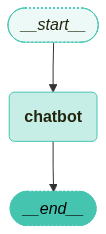

In [7]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

### 그래프 실행

`stream_graph` 함수를 사용하면 그래프 실행 결과를 스트리밍 방식으로 출력할 수 있습니다. `RunnableConfig`를 통해 재귀 깊이 제한(`recursion_limit`)과 스레드 식별자(`thread_id`)를 설정합니다.

아래 코드는 Config를 설정하고 사용자 입력을 준비합니다.

In [8]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain.messages import HumanMessage

# Config 설정(recursion_limit: 재귀 깊이 제한, thread_id: 스레드 아이디)
config = RunnableConfig(recursion_limit=20, thread_id="abc123")

In [9]:
inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

# 그래프 스트리밍
stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 물론이죠.  
**LangGraph**는 **LLM(대규모 언어 모델) 기반 애플리케이션을 상태(state)와 흐름(flow) 중심으로 설계할 수 있게 해주는 프레임워크**입니다. 쉽게 말하면:

- 일반적인 체인(chain)처럼 “한 번 쭉 실행”하는 것보다
- **분기, 반복, 조건 판단, 여러 에이전트 협업**
- 그리고 **대화/작업 상태를 유지하는 복잡한 워크플로우**

를 만들 때 유용합니다.

---

## 1. LangGraph를 한 줄로 설명하면

**LangChain 생태계에서, 그래프 구조로 LLM 워크플로우를 만드는 도구**입니다.

여기서 “그래프”는 보통 이런 느낌입니다:

- **노드(Node)**: 하나의 작업 단위  
  예: 질문 분석, 검색, 요약, 응답 생성
- **엣지(Edge)**: 다음에 어디로 갈지 연결  
  예: “검색이 필요하면 검색 노드로”, “바로 답할 수 있으면 응답 노드로”

즉, 단순 체인보다 더 유연한 **상태 기반 실행 흐름**을 만들 수 있습니다.

---

## 2. 왜 LangGraph를 쓰나요?

일반적인 LLM 앱은 처음엔 이렇게 시작합니다:

1. 사용자 입력 받기
2. 프롬프트 구성
3. LLM 호출
4. 결과 반환

그런데 조금만 복잡해지면 이런 요구가 생깁니다:

- 검색이 필요하면 검색하고, 아니면 바로 답변하기
- 답변 품질이 낮으면 다시 시도하기
- 여러 도구를 순차/조건부로 사용하기
- 에이전트가 도중에 계획을 수정하기
- 대화 기록이나 작업 상태를 유지하기

이럴 때 LangGraph가 강합니다.

### 장점
- **조건 분기**가 쉬움
- **반복 루프** 구현 가능
- **상태 관리**가 명확함
- **에이전트 워크플로우**에 적합
- **디버깅/구조화**에 유리함

---

## 3. LangChain과는 뭐가 다른가요?

많이 헷갈

---

## 도구(Tools) 추가

외부 검색 도구를 통합하여 실시간 정보를 조회할 수 있는 챗봇을 만듭니다. LangGraph는 LLM이 외부 도구를 호출하고 그 결과를 활용하는 워크플로우를 쉽게 구성할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Tool Integration](https://docs.langchain.com/oss/python/langgraph/tool-integration.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Tool Binding | LLM에 사용 가능한 도구를 연결하는 과정 |
| Tool Node | 실제 외부 API를 호출하는 노드 |
| Conditional Edges | LLM 응답에 따라 도구 사용 여부를 자동 분기 |

아래 코드는 간단한 덧셈 도구를 정의합니다.

In [10]:
# 공유
from langchain.tools import tool


@tool
def add(a: int, b: int):
    "두 숫자를 더합니다."
    return a + b

In [ ]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

# Tavily 검색 도구 설정
tool = TavilySearch(max_results=2)
tools = [tool, add]

# 도구 테스트 
result = tool.invoke("LangGraph란 무엇인가요?")
print(f"검색 결과 수: {len(result['results'])}개")
print(f"첫 번째 결과 제목: {result['results'][0]['title']}")

검색 결과 수: 2개
첫 번째 결과 제목: LangGraph란 무엇인가요? | IBM


### 도구 사용 그래프 구성

기본 챗봇 흐름에 도구 호출 경로를 추가합니다. LLM이 도구 호출을 요청하면 "tools" 노드로 이동하고, 도구 실행 후 다시 챗봇으로 돌아오는 순환 구조(chatbot ⇄ tools)를 구성합니다.

아래 코드는 LLM에 도구를 바인딩합니다.

In [20]:
llm_with_tools = llm.bind_tools(tools)

In [21]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

In [22]:
print(ret1.content)

LangGraph는 **LLM 앱을 “그래프(graph) 형태의 워크플로우”로 구성하는 프레임워크**예요.

쉽게 말하면:

- 일반적인 챗봇은 `입력 → LLM 답변`처럼 한 번에 끝나지만
- LangGraph는 이를 **여러 단계(node)** 로 나누고
- 단계 사이를 **조건 분기, 반복, 상태 저장**으로 연결해서
- **에이전트(agent)나 복잡한 자동화 흐름**을 만들 수 있게 해줍니다.

### 핵심 개념
- **Node**: 하나의 작업 단위  
  예: 검색하기, LLM 호출하기, 도구 실행하기, 결과 검증하기
- **Edge**: 다음 단계로 넘어가는 연결
- **State**: 현재까지의 대화/작업 상태를 저장하는 데이터
- **Conditional routing**: 결과에 따라 다른 노드로 분기
- **Loop**: 목표를 달성할 때까지 반복 실행 가능

### 왜 쓰나?
LangChain만으로도 체인을 만들 수 있지만, LangGraph는 특히 이런 데 강해요:

- **에이전트 구현**
- **멀티스텝 추론**
- **툴 사용 + 재시도**
- **긴 작업 흐름 관리**
- **사람 개입(human-in-the-loop)**
- **상태가 있는 워크플로우**

### 예시
예를 들어 “사용자 질문에 답하기”를 이렇게 만들 수 있어요:

1. 사용자 질문 받기
2. 검색이 필요한지 판단
3. 필요하면 웹 검색
4. 검색 결과 요약
5. 답변 생성
6. 답변이 부족하면 다시 검색

이걸 LangGraph에서는 **그래프로 표현**할 수 있습니다.

### 언제 유용한가?
- 단순 Q&A 챗봇보다
- **판단 → 도구 호출 → 검증 → 재시도**가 필요한
- 더 “에이전트다운” 시스템을 만들 때 유용해요.

### 한 줄 요약
**LangGraph는 LangChain 생태계에서 복잡한 LLM/에이전트 워크플로우를 상태 기반 그래프로 설계하는 도구**입니다.

원하시면 다음으로  
1. **LangChain과 LangGraph 차이**,

In [23]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content: "LangGraph는 **LLM 앱을 “그래프(graph) 형태의 워크플로우”로 구성하는 프레임워크**예요.

쉽게 말하면:

- 일반적인 챗봇은 `입력 → LLM 답변`처럼 한 번에 끝나지만
- LangGraph는 이를 **여러 단계(node)** 로 나누고
- 단계 사이를 **조건 분기, 반복, 상태 저장**으로 연결해서
- **에이전트(agent)나 복잡한 자동화 흐름**을 만들 수 있게 해줍니다.

### 핵심 개념
- **Node**: 하나의 작업 단위  
  예: 검색하기, LLM 호출하기, 도구 실행하기, 결과 검증하기
- **Edge**: 다음 단계로 넘어가는 연결
- **State**: 현재까지의 대화/작업 상태를 저장하는 데이터
- **Conditional routing**: 결과에 따라 다른 노드로 분기
- **Loop**: 목표를 달성할 때까지 반복 실행 가능

### 왜 쓰나?
LangChain만으로도 체인을 만들 수 있지만, LangGraph는 특히 이런 데 강해요:

- **에이전트 구현**
- **멀티스텝 추론**
- **툴 사용 + 재시도**
- **긴 작업 흐름 관리**
- **사람 개입(human-in-the-loop)**
- **상태가 있는 워크플로우**

### 예시
예를 들어 “사용자 질문에 답하기”를 이렇게 만들 수 있어요:

1. 사용자 질문 받기
2. 검색이 필요한지 판단
3. 필요하면 웹 검색
4. 검색 결과 요약
5. 답변 생성
6. 답변이 부족하면 다시 검색

이걸 LangGraph에서는 **그래프로 표현**할 수 있습니다.

### 언제 유용한가?
- 단순 Q&A 챗봇보다
- **판단 → 도구 호출 → 검증 → 재시도**가 필요한
- 더 “에이전트다운” 시스템을 만들 때 유용해요.

### 한 줄 요약
**LangGraph는 LangChain 생태계에서 복잡한 LLM/에이전트 워크플로우를 상태 기반 그래프로 설계하는 도구**입니다.

원하시면 다음으로  
1. **LangChain과 L

In [24]:
display_message_tree(ret2)

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 57
            prompt_tokens: 1301
            total_tokens: 1358
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0, "text_tokens": None}
            prompt_tokens_details: {"audio_tokens": 0, "cache_write_tokens": None, "cached_tokens": 0, "image_tokens": None, "text_tokens": None}
        model_provider: "openai"
        model_name: "gpt-5.4-2026-03-05"
        system_fingerprint: None
        id: "chatcmpl-EVChhtLZIARKbhT7Ao58TuDA7w4B4"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--01a10638-2e24-7420-9630-3bbc2ba3df4b-0"
    tool_calls:
        index [0]
            name: "tavily_search"
            args:
                query: "LangGraph what is LangGraph official do

In [25]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의 (동일)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 새로운 그래프 빌더 생성
builder = StateGraph(State)

# LLM에 도구 바인딩 - LLM이 도구를 사용할 수 있도록 설정
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    # 도구가 바인딩된 LLM 호출
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 노드 추가
builder.add_node("chatbot", chatbot)

# ToolNode 추가 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

### 조건부 라우팅

`tools_condition`이 마지막 AI 메시지의 `tool_calls` 존재 여부를 확인해 경로를 분기합니다.

### tools_condition 동작

`tool_calls` 존재 시 "tools"로, 없으면 "\_\_end\_\_"로 분기합니다.

```python
def tools_condition(state) -> Literal["tools", "__end__"]:
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"
```

In [26]:
# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 정의된 조건 함수 사용
)
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile()

### 그래프 시각화

도구가 연결된 그래프의 구조를 시각화합니다. chatbot 노드에서 조건에 따라 tools 노드로 분기하는 구조를 확인할 수 있습니다.

아래 코드는 도구가 연결된 그래프를 시각화합니다.

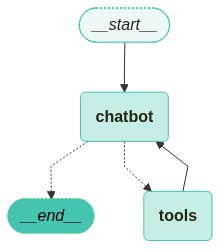

In [27]:
# 그래프 시각화
visualize_graph(graph_with_tools)

### 도구 사용 테스트

Tavily 검색 도구를 활용하여 최신 정보를 검색하는 테스트를 수행합니다. LLM이 질문에 답하기 위해 필요하다고 판단하면 자동으로 검색 도구를 호출합니다.

아래 코드는 2025년 LangGraph 사용 사례에 대한 검색을 수행합니다.

In [28]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025 LangGraph use cases case studies examples 2025 LangGraph applications", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.langchain.com/blog/customers-vodafone-italy", "title": "Fastweb + Vodafone: Transforming Customer Experience with AI Agents using LangGraph and LangSmith", "content": "Try LangSmith\n\nGet a demo\n\nCase Studies\n\nLangGraph\n\nLangSmith\n\n# Fastweb + Vodafone: Transforming Customer Experience with AI Agents using LangGraph and LangSmith\n\nThe LangChain Team\n\nDecember 16, 2025\n\n7\n\nmin\n\nGo back to blog\n\nCreate agents\n\nShare\n\nFastweb + Vodafone, part of the Swisscom Group, is one of Europe's leading telecommunications providers serving millions of customers across Italy. Recognizing that traditional customer service approaches could be improved to meet their g

---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [29]:
from typing import List, Optional
from datetime import datetime
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
import os


# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )


# 기본 시스템 프롬프트
DEFAULT_SYSTEM_PROMPT = """You are an expert memory extraction assistant. Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)"""


def create_memory_extractor(
    model_name: Optional[str] = "openai:gpt-5.4",
    system_prompt: Optional[str] = None,
) -> any:
    """메모리 추출기를 생성합니다.

    Args:
        model: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """
    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT

    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}

Remember to:
- Extract multiple memory items if the conversation contains various pieces of information
- Use clear, consistent key naming conventions
- Preserve context in values when necessary
- Be comprehensive but avoid redundancy
"""

    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        },
    )

    # 모델 설정
    model = init_chat_model(model_name)

    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser

    return memory_extractor

In [30]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

from langchain_teddynote.memory import create_memory_extractor
import uuid

model = init_chat_model("openai:gpt-5.4")
memory_extractor = create_memory_extractor(model="openai:gpt-5.4")


def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> dict[str, Any]:
    """LLM 모델을 호출하고 사용자 메모리를 관리합니다.

    Args:
        state (MessagesState): 메시지를 포함하는 현재 상태
        config (RunnableConfig): 실행 가능 구성
        store (BaseStore): 메모리 저장소
    """
    # 마지막 메시지에서 user_id 추출
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    print(namespace)

    # 유저의 메모리 검색
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([f"{memory.key}: {memory.value}" for memory in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    # LLM 호출
    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}

In [31]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# 그래프 빌드
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

# 메모리 체크포인터 생성
# 실제 프로덕션에서는 PostgresSaver 사용 권장
memory_saver = InMemorySaver()
memory_store = InMemoryStore()

# 그래프 컴파일
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store,
)

In [32]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

In [33]:
# 메시지, thread_id, user_id 전달
run_graph("안녕? 내 이름은 테디야", "1", "someone")


[유저] 안녕? 내 이름은 테디야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕, 테디! 만나서 반가워 😊  
무엇을 도와줄까?


In [34]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디! 😊


In [35]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
아직 이름을 알려주지 않으셨어요.  
원하시면 지금 알려주시면 제가 그 이름으로 불러드릴게요.


### 장기 기억 저장

메시지에 `remember` 키워드 포함 시 장기 저장소에 정보를 기록합니다.

In [36]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 테디야 remember", "2", "someone")


[유저] 내 이름이 테디야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "user_name",
      "value": "테디",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 이름이 테디라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='user_name' value='테디' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠어요, 테디!  
이제 테디라고 부를게요.


### Thread 간 지속성

User ID 기반 장기 기억은 Thread가 달라도 유지됩니다.

In [37]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디라고 하셨어요.


In [38]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "preference",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 AI Engineer로 일하며, 취미는 Netflix 시청임을 밝혔다.",
  "timestamp": "2024-06-19T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='preference' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
기억해둘게요:

- 직업: AI Engineer
- 취미: Netflix 보기

앞으로 대화할 때 참고

In [39]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디님 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


In [40]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
제가 현재 알고 있는 정보로는 사용자의 **이름, 직업, 취미**를 알 수 없어요.

원하시면 지금 알려주시면 제가 기억해서 이후 대화에서 반영할 수 있어요.  
예:  
- 이름: 민수  
- 직업: 디자이너  
- 취미: 등산, 게임


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [41]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f1c0060-00a6-6d6a-8001-fbbbb6199c2b

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 테디님 정보는 다음과 같아요:

- 이름: 테디
- 직업: AI Engineer
- 취미: Netflix 보기


---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [42]:
from langchain.tools import tool
from langgraph.types import Command, interrupt


@tool
def human_assistance(query: str) -> str:
    """Request assistance from an expert(human)."""
    # interrupt를 호출하여 실행 일시 중지
    # 사람의 응답을 기다림
    human_response = interrupt({"query": query})

    # 사람의 응답 반환
    return human_response["data"]

### HITL 그래프 구성

`human_assistance` 도구를 사용하는 그래프를 구성합니다. 이 도구가 호출되면 `interrupt`로 실행이 중단되고, 사람의 응답을 기다립니다. 응답이 입력되면 해당 내용을 반환하여 대화를 계속합니다.

아래 코드는 Human-in-the-Loop 기능이 포함된 그래프를 구성합니다.

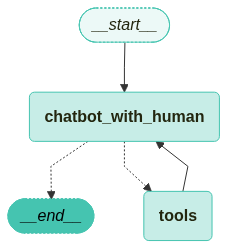

In [43]:
# 도구 리스트 업데이트
tools_with_human = [human_assistance]

# 새로운 그래프 구성
graph_builder_hitl = StateGraph(State)

# LLM에 도구 바인딩
llm_with_human_tools = llm.bind_tools(tools_with_human)


def chatbot_with_human(state: State):
    """Human Interuption 요청할 수 있는 챗봇"""
    message = llm_with_human_tools.invoke(state["messages"])

    # interrupt 중 병렬 도구 호출 방지
    # (재개 시 도구 호출이 반복되는 것을 방지)
    if hasattr(message, "tool_calls"):
        assert (
            len(message.tool_calls) <= 1
        ), "병렬 도구 호출은 interrupt와 함께 사용할 수 없습니다"

    return {"messages": [message]}


# 노드 추가
graph_builder_hitl.add_node("chatbot_with_human", chatbot_with_human)

# ToolNode 추가
tool_node_hitl = ToolNode(tools=tools_with_human)
graph_builder_hitl.add_node("tools", tool_node_hitl)

# 엣지 추가
graph_builder_hitl.add_conditional_edges("chatbot_with_human", tools_condition)
graph_builder_hitl.add_edge("tools", "chatbot_with_human")
graph_builder_hitl.add_edge(START, "chatbot_with_human")

# 메모리와 함께 컴파일
memory_hitl = InMemorySaver()
graph_hitl = graph_builder_hitl.compile(checkpointer=memory_hitl)

# 그래프 시각화
visualize_graph(graph_hitl)

### HITL 테스트

사람에게 조언을 요청하는 질문으로 interrupt와 재개 흐름을 검증합니다. 그래프가 중단되면 `get_state`로 현재 상태를 확인하고, `Command(resume=...)`로 재개할 수 있습니다.

아래 코드는 인간 지원을 요청하는 메시지로 그래프를 실행합니다.

In [44]:
from langchain_teddynote.messages import random_uuid

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")

stream_graph(
    graph_hitl,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)

User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [45]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = graph_hitl.get_state(config_hitl)
print(f"\n현재 상태:")
print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")


현재 상태:
  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f1c0064-8199-6202-8001-61bb6818c970


In [46]:
# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
stream_graph(graph_hitl, inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)



🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
사람 설명 느낌으로 쉽게 말하면, **LangGraph는 “LLM 앱의 흐름도를 코드로 만드는 도구”**예요.  
챗봇이나 에이전트를 만들다 보면 단순히 “질문 → 답변”으로 끝나지 않고, 중간에 **검색도 하고, 판단도 하고, 필요하면 다시 시도하고, 사람 승인도 받고, 여러 단계로 나뉘는 흐름**이 생기거든요. LangGraph는 이런 복잡한 흐름을 **그래프 구조(node, edge)**로 짜게 해줘요.  
예를 들면:  
**질문 받기 → 필요한 정보 검색 → 답변 초안 만들기 → 검토 → 부족하면 다시 검색 → 최종 답변**  
이런 식의 순환 구조를 만들기 좋습니다.

**LangChain과의 관계**를 비유하면, LangChain은 LLM 앱을 만들 때 쓰는 **부품 상자**에 가깝고, LangGraph는 그 부품들을 연결해서 **상태 있는 워크플로우**를 만드는 도구예요. 특히 “에이전트가 중간에 어떤 결정을 내리고, 다음에 어디로 갈지 선택하는” 상황에 강합니다. 그래서 단순 Q&A보다 **멀티스텝 에이전트, 도구 호출, 사람 개입, 긴 작업 흐름 관리**가 필요한 경우에 많이 

---

## 상태 커스터마이징

메시지 외에 업무 데이터를 다루는 커스텀 상태와 도구 기반 상태 업데이트를 도입합니다. `Command` 객체를 사용하면 도구 실행 결과로 상태를 직접 갱신할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Custom State Fields | messages 외에 추가 필드를 정의 |
| State Updates from Tools | 도구 결과로 상태를 직접 갱신 |
| Command(update=...) | 상태 업데이트를 지정하는 명령 객체 |

아래 코드는 `human_feedback` 필드가 추가된 커스텀 상태를 정의합니다.

In [47]:
from langchain.messages import ToolMessage
from langchain.tools import InjectedToolCallId


# 확장된 State 정의
class CustomState(TypedDict):
    """커스텀 필드가 추가된 상태"""

    messages: Annotated[list, add_messages]
    human_feedback: str  # 사람의 피드백

### 상태 업데이트 도구

도구 실행 결과를 `Command(update=...)`로 상태에 반영합니다. 이 패턴을 사용하면 도구가 단순히 문자열을 반환하는 것이 아니라, 상태의 특정 필드를 직접 수정할 수 있습니다.

아래 코드는 인간 검토를 요청하고 피드백에 따라 상태를 업데이트하는 도구를 정의합니다.

In [48]:
@tool
def human_review(
    human_feedback, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request human review for information."""
    # 인간에게 검토 요청
    human_response = interrupt(
        {"question": "이 정보가 맞나요?", "human_feedback": human_feedback}
    )

    feedback = human_response.get("human_feedback", "")

    if feedback.strip() == "":
        # 사용자가 AI 의 답변에 동의하는 경우
        return Command(
            update={
                "messages": [ToolMessage(human_response, tool_call_id=tool_call_id)]
            }
        )
    else:
        # 사용자가 AI 의 답변에 동의하지 않는 경우
        corrected_information = f"# 사용자에 의해 수정된 피드백: {feedback}"
        return Command(
            update={
                "messages": [
                    ToolMessage(corrected_information, tool_call_id=tool_call_id)
                ]
            }
        )

### 커스텀 상태 그래프

`CustomState`를 사용하여 그래프를 구성합니다. 기본 `State` 대신 커스텀 상태를 사용하면 애플리케이션에 필요한 추가 데이터를 관리할 수 있습니다.

아래 코드는 커스텀 상태와 `human_review` 도구를 사용하는 그래프를 구성합니다.

In [49]:
# 도구 리스트
tools_custom = [human_review]

# 새로운 그래프 구성
custom_graph_builder = StateGraph(CustomState)  # CustomState 사용

# LLM에 도구 바인딩
llm_with_custom_tools = llm.bind_tools(tools_custom)


def chatbot_custom(state: CustomState):
    """커스텀 상태를 사용하는 챗봇"""
    message = llm_with_custom_tools.invoke(state["messages"])

    if hasattr(message, "tool_calls"):
        assert len(message.tool_calls) <= 1

    return {"messages": [message]}


# 노드와 엣지 추가
custom_graph_builder.add_node("chatbot", chatbot_custom)
tool_node_custom = ToolNode(tools=tools_custom)
custom_graph_builder.add_node("tools", tool_node_custom)

custom_graph_builder.add_conditional_edges("chatbot", tools_condition)
custom_graph_builder.add_edge("tools", "chatbot")
custom_graph_builder.add_edge(START, "chatbot")

# 컴파일
memory_custom = InMemorySaver()
custom_graph = custom_graph_builder.compile(checkpointer=memory_custom)

### 그래프 시각화

커스텀 상태 그래프의 구조를 시각화합니다. 기본 도구 그래프와 동일한 구조이지만, 내부적으로 `CustomState`를 사용합니다.

아래 코드는 커스텀 상태 그래프를 시각화합니다.

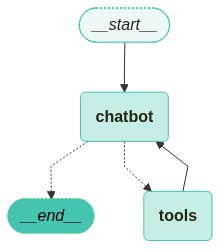

In [50]:
# 그래프 시각화
visualize_graph(custom_graph)

### 커스텀 상태 테스트

`human_review` 도구 호출 시 interrupt로 중단되고, 재개 시 사용자 피드백에 따라 상태가 갱신되는지 확인합니다. 사용자가 빈 피드백을 제공하면 AI의 답변에 동의하는 것으로 처리됩니다.

아래 코드는 인간 검토가 필요한 질문으로 그래프를 실행합니다.

In [51]:
# LangGraph의 출시일을 조사하고 검토 요청
user_input = (
    "2024년 노벨 문학상 수상자가 누구인지 조사해주세요. "
    "답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요."
)

custom_config = RunnableConfig(configurable={"thread_id": random_uuid()})

print(f"User: {user_input}\n")

# 실행 (interrupt에서 중단될 것임)
stream_graph(
    custom_graph,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=custom_config,
)

User: 2024년 노벨 문학상 수상자가 누구인지 조사해주세요. 답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요.


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [52]:
from langchain_teddynote.messages import display_message_tree

# 최신 메시지 가져오기
last_message = custom_graph.get_state(custom_config).values["messages"][-1]

# 최신 메시지 tree 구조로 표시
display_message_tree(last_message)

    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-5.4-2026-03-05", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--01a1077c-90d0-7c83-87a2-7565a4532999"
    tool_calls:
        index [0]
            name: "human_review"
            args:
                human_feedback: {"claim": "2024년 노벨 문학상 수상자는 한강(Han Kang)입니다.", "source_basis": "노벨상 공식 발표에 따르면 2024년 노벨 문학상은 한국의 작가 한강에게 수여되었습니다."}
            id: "call_2DoLotCswqt1A4D1Fbgpdm3I"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 160
        output_tokens: 70
        total_tokens: 230
        input_token_details: {"audio": 0, "cache_read": 0}
        output_token_details: {"audio": 0, "reasoning": 0}


In [53]:
# AI 가 작성한 내용
print(last_message.tool_calls[0]["args"]["human_feedback"])

{'claim': '2024년 노벨 문학상 수상자는 한강(Han Kang)입니다.', 'source_basis': '노벨상 공식 발표에 따르면 2024년 노벨 문학상은 한국의 작가 한강에게 수여되었습니다.'}


In [54]:
# 인간의 검토 응답으로 재개
human_command = Command(
    resume={"human_feedback": "2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다."}
)

stream_graph(custom_graph, inputs=human_command, config=custom_config)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 사용자에 의해 수정된 피드백: 2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2024년 노벨 문학상 수상자는 대한민국의 작가 **한강**입니다.

---

# 🧩 1주차 퀴즈 ③ — LangGraph QuickStart

빈칸(`________`)을 채우고 실행해보세요. 제출 방법은 퀴즈 ①(01-LangGraph-Introduction.ipynb)의 안내와 같습니다.

> ⚠️ 이 퀴즈는 **OpenAI API 키**(`.env`)가 필요합니다.

### Q1. 기본 챗봇 그래프 만들기

노드 추가 → 엣지 연결 → 컴파일까지, StateGraph의 기본 3단계를 완성하세요.

In [56]:
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

load_dotenv(override=True)


class State(TypedDict):
    messages: Annotated[list, add_messages]


llm = init_chat_model("openai:gpt-5.4-mini")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)

# 1) "chatbot"이라는 이름으로 노드를 추가하세요
builder.add_node("chatbot", chatbot)


# 2) 시작점 → chatbot → 종료점 엣지를 연결하세요
builder.add_edge(START , "chatbot")
builder.add_edge("chatbot", END)

# 3) 그래프를 실행 가능한 형태로 변환하세요
graph = builder.compile()

result = graph.invoke({"messages": [("user", "안녕! 반가워.")]})
print(result["messages"][-1].content)

# ---- 자동 채점: 컴파일된 그래프의 실제 구조를 확인합니다 ----
node_names = set(graph.get_graph().nodes.keys())
edges = {(e.source, e.target) for e in graph.get_graph().edges}

assert "chatbot" in node_names, '"chatbot" 노드가 추가되어야 합니다'
assert ("__start__", "chatbot") in edges, "START → chatbot 엣지가 필요합니다"
assert ("chatbot", "__end__") in edges, "chatbot → END 엣지가 필요합니다"
assert result["messages"][-1].content, "LLM의 답변이 비어 있으면 안 됩니다"
print("통과! 🎉")

안녕! 반가워요 😊  
무엇을 도와드릴까요?
통과! 🎉


### Q2. 도구와 조건부 라우팅

chatbot ⇄ tools 순환 구조를 완성하세요. LLM이 도구 호출을 요청하면 tools 노드로, 아니면 END로 분기해야 합니다.

In [57]:
from langchain.tools import tool
from langchain.messages import ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """두 숫자를 곱합니다."""
    return a * b


tools = [multiply]
llm_with_tools = llm.bind_tools(tools)


def chatbot_with_tools(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("chatbot", chatbot_with_tools)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "chatbot")

# 1) tool_calls 유무에 따라 분기하는 '조건부 엣지'를 추가하세요
builder.add_conditional_edges("chatbot", tools_condition)

# 2) 도구 실행 후 다시 chatbot으로 돌아가는 엣지를 추가하세요
builder.add_edge("tools", "chatbot")

graph_with_tools = builder.compile()

result = graph_with_tools.invoke(
    {"messages": [("user", "127 곱하기 89는? multiply 도구를 사용해서 계산해줘")]}
)
print(result["messages"][-1].content)

# ---- 자동 채점: 조건부 분기 + 순환 구조 + 도구가 '실제로' 실행됐는지 확인합니다 ----
g = graph_with_tools.get_graph()
edges = {(e.source, e.target) for e in g.edges}
conditional = {(e.source, e.target) for e in g.edges if e.conditional}

assert ("chatbot", "tools") in conditional, "chatbot → tools는 '조건부' 엣지여야 합니다 (일반 add_edge가 아니에요!)"
assert ("tools", "chatbot") in edges, "도구 실행 후 다시 chatbot으로 돌아가는 엣지가 필요합니다"

tool_msgs = [m for m in result["messages"] if isinstance(m, ToolMessage)]
assert tool_msgs, "multiply 도구가 실제로 호출되지 않았어요"
assert "11303" in tool_msgs[0].content, "multiply 실행 결과가 11303이어야 합니다"
print("통과! 🎉")

127 × 89 = 11303
통과! 🎉


### Q3. 메모리 추가

체크포인터를 연결하고, 같은 대화 세션을 이어가도록 config를 설정하세요. 챗봇이 이름을 기억하면 성공입니다.

In [58]:
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 1) InMemorySaver 체크포인터를 연결해서 컴파일하세요 (키워드 인자 이름이 빈칸!)
memory = InMemorySaver()
graph_with_memory = builder.compile(checkpointer=memory)

# 2) 같은 대화를 이어가려면 config에 어떤 키를 지정해야 할까요?
config = {"configurable": {"thread_id": "quiz-thread-1"}}

graph_with_memory.invoke({"messages": [("user", "내 이름은 홍길동이야")]}, config)
result = graph_with_memory.invoke({"messages": [("user", "내 이름이 뭐라고?")]}, config)
print(result["messages"][-1].content)

# ---- 자동 채점: 체크포인터가 대화를 정말로 기억하는지 확인합니다 ----
saved = graph_with_memory.get_state(config).values["messages"]
assert len(saved) >= 4, "두 번의 대화(사용자 2 + AI 2)가 체크포인터에 쌓여 있어야 합니다"
assert "홍길동" in result["messages"][-1].content, "챗봇이 이름을 기억하지 못했어요. 두 호출의 thread_id가 같은지 확인하세요"
print("통과! 🎉")

홍길동입니다.
통과! 🎉


### Q4. 개념 확인 (주관식)

이 셀을 **더블클릭**해서 아래 질문에 직접 답을 작성하세요.

1. `interrupt()`로 중단된 그래프를 사람의 응답과 함께 재개할 때 사용하는 객체는 무엇일까요?
   - 답: command 객체

2. Q3에서 같은 `thread_id`로 대화하면 이전 대화가 기억되는 이유는 무엇일까요? (체크포인터의 역할과 연결해서 1-2문장)
   - 답:checkpointer가 각 thread에 대해 메모리 저장. thread_id로 다시 실행하면 저장된 상태가 불러와짐

3. State의 `messages` 필드에 `add_messages` 리듀서가 없다면, 노드가 실행될 때마다 `messages`는 어떻게 될까요?
   - 답:새 message가 기존을 대체해서 이전 메세지가 누적되지 않음